# Introduction to Using Neural Networks for Images: Convolutional Neural Networks

Author: Dr. Julie Butler

Date Created: June 30, 2026

Last Modified: July 22, 2026

Created for the _University of Mount Union Data Science Summer Camp_, July 31 and August 1, 2026.

## Introduction

In our first session, we built a [neural network](https://en.wikipedia.org/wiki/Neural_network_(machine_learning)) that could predict whether a passenger on the Titanic survived. That network worked with a small number of **features** (like passenger class and fare), and every input was connected to every neuron in the next layer. This works great for a handful of numbers, but what happens when we want a computer to look at a *picture*?

In this session, we will learn about a special kind of neural network called a [**Convolutional Neural Network**](https://en.wikipedia.org/wiki/Convolutional_neural_network), or **CNN** for short. CNNs are the technology behind facial recognition, self-driving cars, medical image analysis, and the photo filters on your phone. 

## Why CNNs Exist

To a computer, an image is a grid of numbers representing pixel brightness. A 28 × 28 grayscale image holds **784 numbers**.

The problem: regular neural networks connect *every* input to *every* neuron. A 200 × 200 color photo is 200 × 200 × 3 = **120,000 numbers**, which would create billions of connections — too slow, too data-hungry, and prone to [overfitting](https://en.wikipedia.org/wiki/Overfitting).

Regular networks treat distant and adjacent pixels alike, discarding the fact that **nearby pixels are related** and form edges, shapes, and objects.

CNNs solve this by mimicking how we actually recognize things:
1. **Look for features** (edges, shapes, textures) rather than memorizing exact pixels.
2. **Find those features anywhere** in the image.

The building block is a [**filter**](https://en.wikipedia.org/wiki/Kernel_(image_processing)) (or **kernel**) — a small window, often 3 × 3, that slides across the image hunting for **one specific pattern**. Its output is a [**feature map**](https://en.wikipedia.org/wiki/Convolutional_neural_network#Feature_maps) showing where that pattern occurs.

Because the **same filter is reused at every position**, there are far fewer numbers to learn, and features get detected regardless of location. That sliding action is a **convolution** — hence "Convolutional" in CNN.

## A Demonstration
This website, [CNN Explainer](https://poloclub.github.io/cnn-explainer/), helps to demonstrate how a CNN can take an image and pull out meaningful information. Note that it does take quite a long time to load. Sometimes pressing refresh will make it load a bit faster.

Note that there is one thing in most CNN implementations that not shown in this CNN Explainer. After the convolutional layers and pooling layers, before the final decision is made, there are usually one or more "normal" (feedforward) neural network layers. The idea is that these layers will take the feature map refined by the convolutional and pooling layers and further refine the data and find patterns before the final determination is made.

## A Python Implementation

In [1]:
#############
## IMPORTS ##
#############
# All of the importants and some code are in the CNN_Wrapper.py file. This is just a wrapper to make it 
# easier to use the CNN class. If you want to see the code for the CNN class, you can look in the 
# CNN_Wrapper.py file, but don't worry about understanding it for now. Just know that you can use the CNN 
# class to create a convolutional neural network and train it on your data.
from CNN_Wrapper import *

In [2]:
###################
## LOAD THE DATA ##
###################
# get_mnist_data is a function that loads the MNIST dataset and returns the training and test data as 
# PyTorch DataLoader objects. The batch_size parameter specifies how many samples per batch to load.
# You can change the batch_size to a different value if you want.

# Note that this data is already preprocessed and normalized, so you don't need to do any additional preprocessing. 
# The images are 28x28 grayscale images of clothing, and the labels are the corresponding clothing categories.
train_data, test_data = get_mnist_data(batch_size=64)

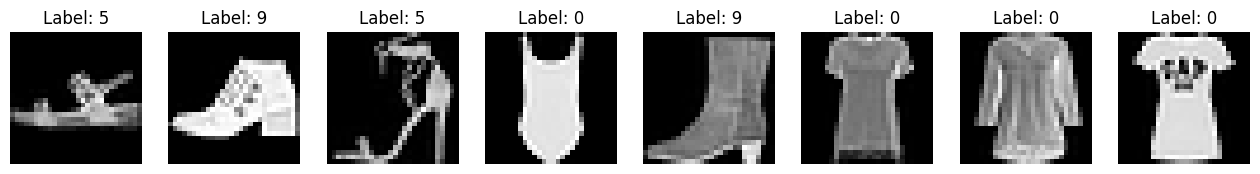

In [3]:
########################
## DATA VISUALIZATION ##
########################
# Visualize some of the training data to get a sense of what the images look like.
visualize_data(train_data, num_images=8)

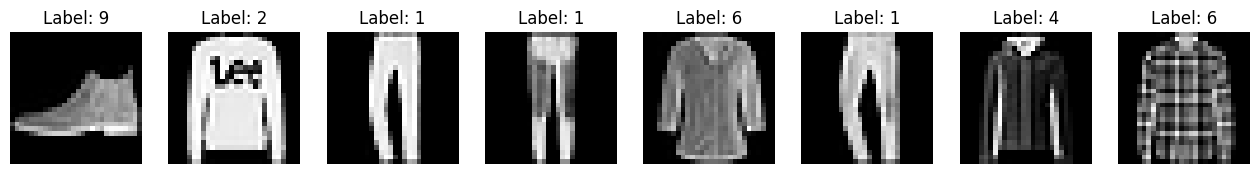

In [4]:
visualize_data(test_data, num_images=8)

In [8]:
####################
## DEFINE THE CNN ##
####################
# build_cnn is a function that creates a convolutional neural network (CNN) model, loss function, 
# and optimizer based on the specified parameters. You can change the parameters to create different CNN architectures.
model, criterion, optimizer, device = build_cnn(
                                        conv_channels=(4, 8),
                                        kernel_size=3,
                                        pool_size=2,
                                        hidden_neurons=4,
                                        dropout=0.25,
                                        activation="relu",
                                        learning_rate=1e-2,
                            )

### Explaination of the Hyperparameters

* `conv_channels = (32, 64)` — Two convolutional layers: the first uses 32 filters, the second 64. Early layers find simple edges; later ones combine them into more complex shapes, so they need more filters.
* `kernel_size = 3` — Each filter window is 3×3 pixels, sliding across the image to catch local details like edges and corners.
* `pool_size = 2` — The "zooming out" step. Takes 2×2 blocks and keeps only the most important value, halving width and height. Faster, and less fussy about exactly where a feature sits.
* `hidden_neurons = 128` — The size of the regular decision-making layer that runs after the filters. More neurons mean more "room to think," but too many slow things down or encourage memorizing.
* `dropout = 0.25` — Anti-overfitting trick: randomly switches off 25% of neurons each training round. Like a team practicing with random players benched, it stops the network from leaning on any single neuron.
* `activation = "relu"` — The rule inside each neuron for what signal to pass on. ReLU keeps positives, zeros out negatives, adding the "bend" that lets the network learn curvy patterns. Alternatives: `"tanh"`, `"sigmoid"`.
* `learning_rate=1e-3` — How big a step the network takes when adjusting itself. 1e-3 (0.001) is a reliable middle ground: too big overshoots, too small crawls.

In [9]:

###################
## TRAIN THE CNN ##
###################
epochs = 3
for epoch in range(1, epochs + 1):
    loss = train(model, train_data, optimizer, criterion, device)
    print("Epoch:", epoch, "Training Loss:", loss)
    

Epoch: 1 Training Loss: 1.8912085479100544
Epoch: 2 Training Loss: 1.8469143224080404
Epoch: 3 Training Loss: 1.8215823673884073


In [10]:
acc = evaluate(model, test_data, device)
print("Test accuracy:", acc*100, "%")

Test accuracy: 40.050000000000004 %


## Challenge

Perform _hyperparameter tuning_ by changing the batch size (from the `get_mnist_data` function) and all of the hyperparameters defined in the `build_cnn` function. You can also change the `epochs` defined above the training loop. Try as many different combinations as possible in order to get the highest test accuraccy possible!

**WARNING:** If you add too many filters using the`'conv_channels` variable or make the decision making layer, `hidden_neurons`, too large or have too many epochs then the time needed to train your neural network will be quite large.

## Conclusion and Future Directions

If you tried the challenge, you probably noticed something important: you never changed the *data*, and you never changed the *code* — but your accuracy still moved around a lot. That's **hyperparameter tuning**, and it's one of the most important skills in machine learning.

A neural network learns its own internal numbers (the **parameters**) during training. But the choices *you* make — how many filters, how big the learning rate, how many epochs — are the **hyperparameters**, and the network can't learn those for itself. Picking them well is often the difference between a model that's 85% accurate and one that's 99% accurate. Real ML engineers and AI researchers spend a huge amount of their time on exactly this, and there are automated tools like [grid search and random search](https://scikit-learn.org/stable/modules/grid_search.html) that try hundreds of combinations for you.

There's no formula that gives you the perfect settings. Tuning is experimental: change one thing, see what happens, keep what works. That habit — form a hypothesis, test it, learn from the result — is the same one used across science, and it's the real skill worth taking away from today.

Where to go next:
* Try a harder dataset like [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) (color photos of animals and vehicles) instead of grayscale digits.
* Look into [**transfer learning**](https://www.tensorflow.org/tutorials/images/transfer_learning), where you start from a giant model someone else already trained and adapt it to your own problem.
* Explore what CNNs are used for beyond classification: medical imaging, self-driving cars, and detecting objects in video.

## Resources for Further Investigation

* [3Blue1Brown: But what is a neural network?](https://www.youtube.com/watch?v=aircAruvnKk) — the best visual introduction to neural networks out there.
* [CNN Explainer](https://poloclub.github.io/cnn-explainer/) — an interactive website that lets you watch a CNN process an image layer by layer.
* [TensorFlow Playground](https://playground.tensorflow.org/) — tune hyperparameters in your browser and watch the network learn in real time.
* [Google's Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course) — free, beginner-friendly, and goes well beyond what we covered today.
* [Kaggle Learn](https://www.kaggle.com/learn) — short hands-on courses plus real datasets to practice on.
* [PyTorch Beginner Tutorial](https://pytorch.org/tutorials/beginner/basics/intro.html) — if you want to write the code that's hidden inside `CNN_Wrapper.py` yourself.